# 🔭 Assignment: Measuring Cosmological Parameters Using Type Ia Supernovae

In this assignment, we'll analyze observational data from the Pantheon+SH0ES dataset of Type Ia supernovae to measure the Hubble constant $H_0$ and estimate the age of the universe. We will:

- Plot the Hubble diagram (distance modulus vs. redshift)
- Fit a cosmological model to derive $H_0$ and $\Omega_m$
- Estimate the age of the universe
- Analyze residuals to assess the model
- Explore the effect of fixing $\Omega_m$
- Compare low-z and high-z results


## 📦 Getting Started: Setup and Libraries

Before we dive into the analysis, we need to import the necessary Python libraries:

- `numpy`, `pandas` — for numerical operations and data handling
- `matplotlib` — for plotting graphs
- `scipy.optimize.curve_fit` and `scipy.integrate.quad` — for fitting cosmological models and integrating equations
- `astropy.constants` and `astropy.units` — for physical constants and unit conversions


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.constants import c
from astropy import units as u

## 📂 Load the Pantheon+SH0ES Dataset

We now load the observational supernova data from the Pantheon+SH0ES sample. This dataset includes calibrated distance moduli $\mu$, redshifts corrected for various effects, and uncertainties.

### Requirements:
- We will download the data file from [Pantheon dataset](https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat) and make it available locally.

We will extract:
- `zHD`: Hubble diagram redshift
- `MU_SH0ES`: Distance modulus using SH0ES calibration
- `MU_SH0ES_ERR_DIAG`: Associated uncertainty


In [27]:
# Load the file
import os
file_path = 'Pantheon+SH0ES.dat'
data = pd.read_csv(file_path, sep='\s+', comment='#')

# See structure
print("\n" + "="*50 + "\n")
print("--- DataFrame Shape ---")
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.")
print("--- First 5 Rows ---")
print(data.head())
print("\n" + "="*50 + "\n")



--- DataFrame Shape ---
The dataset has 1701 rows and 47 columns.
--- First 5 Rows ---
             CID  IDSURVEY      zHD   zHDERR     zCMB  zCMBERR     zHEL  \
0         2011fe        51  0.00122  0.00084  0.00122  0.00002  0.00082   
1         2011fe        56  0.00122  0.00084  0.00122  0.00002  0.00082   
2         2012cg        51  0.00256  0.00084  0.00256  0.00002  0.00144   
3         2012cg        56  0.00256  0.00084  0.00256  0.00002  0.00144   
4  1994DRichmond        50  0.00299  0.00084  0.00299  0.00004  0.00187   

   zHELERR  m_b_corr  m_b_corr_err_DIAG  ...  PKMJDERR  NDOF   FITCHI2  \
0  0.00002   9.74571           1.516210  ...    0.1071    36   26.8859   
1  0.00002   9.80286           1.517230  ...    0.0579   101   88.3064   
2  0.00002  11.47030           0.781906  ...    0.0278   165  233.5000   
3  0.00002  11.49190           0.798612  ...    0.0667    55  100.1220   
4  0.00004  11.52270           0.880798  ...    0.0522   146  109.8390   

    FITPROB  m_

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\pshas\AppData\Local\Temp\ipykernel_26064\187287558.py:4: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(file_path, sep='\s+', comment='#')


## 🧾 Preview Dataset Columns
Before diving into the analysis, let’s take a quick look at the column names in the dataset. This helps us verify the data loaded correctly and identify the relevant columns we’ll use for cosmological modeling.

In [26]:
print("--- DataFrame Info ---")
data.info()
print("\n" + "="*50 + "\n")


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1701 entries, 0 to 1700
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CID                   1701 non-null   object 
 1   IDSURVEY              1701 non-null   int64  
 2   zHD                   1701 non-null   float64
 3   zHDERR                1701 non-null   float64
 4   zCMB                  1701 non-null   float64
 5   zCMBERR               1701 non-null   float64
 6   zHEL                  1701 non-null   float64
 7   zHELERR               1701 non-null   float64
 8   m_b_corr              1701 non-null   float64
 9   m_b_corr_err_DIAG     1701 non-null   float64
 10  MU_SH0ES              1701 non-null   float64
 11  MU_SH0ES_ERR_DIAG     1701 non-null   float64
 12  CEPH_DIST             1701 non-null   float64
 13  IS_CALIBRATOR         1701 non-null   int64  
 14  USED_IN_SH0ES_HF      1701 non-null   int64  
 15

## 🧹 Clean and Extract Relevant Data

To ensure reliable fitting, we remove any rows that have missing values in key columns:

- `zHD`: redshift for the Hubble diagram  
- `MU_SH0ES`: distance modulus  
- `MU_SH0ES_ERR_DIAG`: uncertainty in the distance modulus  

We then extract these cleaned columns as NumPy arrays to prepare for analysis and modeling.


In [25]:
cleaned_data = data.dropna()

redshift_z = cleaned_data['zHD'].to_numpy()
distance_modulus_µ  = cleaned_data['MU_SH0ES'].to_numpy()
dist_mod_err_data_σ = cleaned_data['MU_SH0ES_ERR_DIAG'].to_numpy()

print("Shape of original data:", data.shape)
print("Shape of data after removing blank rows:", cleaned_data.shape)
print("\nFirst 5 values of the redshift (z) NumPy array:")
print(redshift_z[:5])

Shape of original data: (1701, 47)
Shape of data after removing blank rows: (1701, 47)

First 5 values of the redshift (z) NumPy array:
[0.00122 0.00122 0.00256 0.00256 0.00299]


## 📈 Plot the Hubble Diagram

Let’s visualize the relationship between redshift $z$ and distance modulus $\mu$, known as the Hubble diagram. This plot is a cornerstone of observational cosmology—it allows us to compare supernova observations with theoretical predictions based on different cosmological models.

We use a logarithmic scale on the redshift axis to clearly display both nearby and distant supernovae.


Generating plot with a linear x-axis...


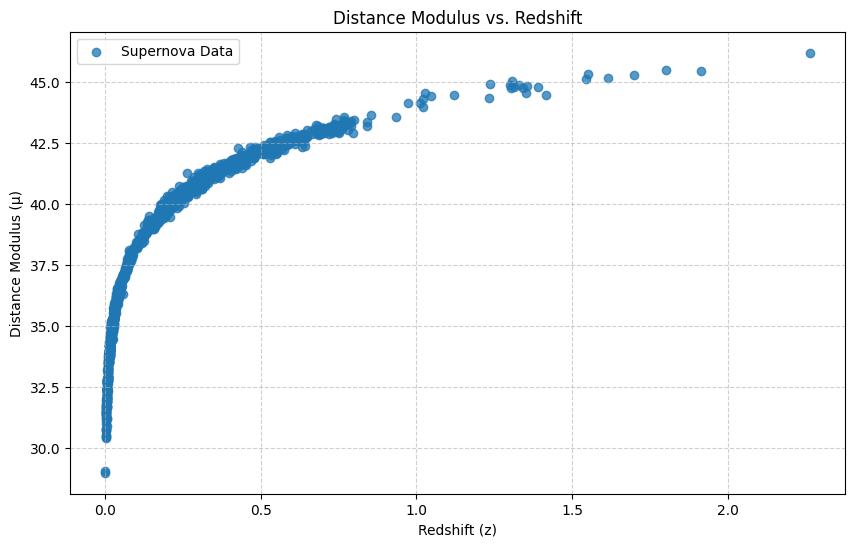


Generating plot with a logarithmic x-axis...


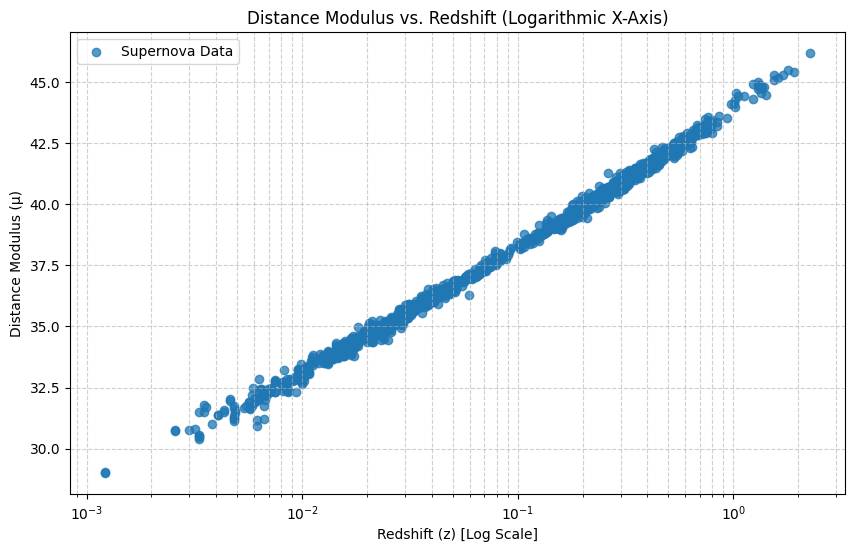

In [24]:

# --- Plot 1: Standard Linear Scale ---

print("Generating plot with a linear x-axis...")
plt.figure(figsize=(10, 6))
plt.scatter(redshift_z, distance_modulus_µ, alpha=0.75, label='Supernova Data')
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (μ)") 
plt.title("Distance Modulus vs. Redshift")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


# --- Plot 2: Logarithmic X-Axis ---

print("\nGenerating plot with a logarithmic x-axis...")
plt.figure(figsize=(10, 6))
plt.scatter(redshift_z, distance_modulus_µ, alpha=0.75, label='Supernova Data')
plt.xscale('log')
plt.xlabel("Redshift (z) [Log Scale]")
plt.ylabel("Distance Modulus (μ)")
plt.title("Distance Modulus vs. Redshift (Logarithmic X-Axis)")
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.show()




## 🧮 Define the Cosmological Model

We now define the theoretical framework based on the flat $\Lambda\mathrm{CDM}$ model. This involves:

- The dimensionless Hubble parameter:
  $$
  E(z) = \sqrt{\Omega_m (1+z)^3 + (1 - \Omega_m)}
  $$

- The distance modulus is:
  $$
  \mu(z) = 5 \log_{10}(d_L / \text{Mpc}) + 25
  $$

- And the corresponding luminosity distance :
  
  $$
  d_L(z) = (1 + z) \cdot \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}
  $$

These equations allow us to compute the expected distance modulus from a given redshift $z$, Hubble constant $H_0$, and matter density parameter $\Omega_m$.


In [21]:


SPEED_OF_LIGHT = 299792.458

# --- Function Definitions for the Cosmological Model ---

def E(z, Omega_m):
    Omega_L = 1.0 - Omega_m
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

def luminosity_distance(z, H0, Omega_m):
    integrand = lambda z_prime: 1 / E(z_prime, Omega_m)
    integral, _ = quad(integrand, 0, z)
    return (SPEED_OF_LIGHT / H0) * (1 + z) * integral

def mu_theory(z_array, H0, Omega_m):
    distances_Mpc = [luminosity_distance(z, H0, Omega_m) for z in z_array]
    return 5 * np.log10(distances_Mpc) + 25



## 🔧 Fit the Model to Supernova Data

We now perform a non-linear least squares fit to the supernova data using our theoretical model for $\mu(z)$. This fitting procedure will estimate the best-fit values for the Hubble constant $ H_0$ and matter density parameter $\Omega_m$, along with their associated uncertainties.

We'll use:
- `curve_fit` from `scipy.optimize` for the fitting.
- The observed distance modulus \(\mu\), redshift \(z\), and measurement errors.

The initial guess is:
- $ H_0 = 70 \, \text{km/s/Mpc} $
- $\Omega_m =0.3$


Fitted H0 = 72.97 ± 0.26 km/s/Mpc
Fitted Omega_m = 0.351 ± 0.019


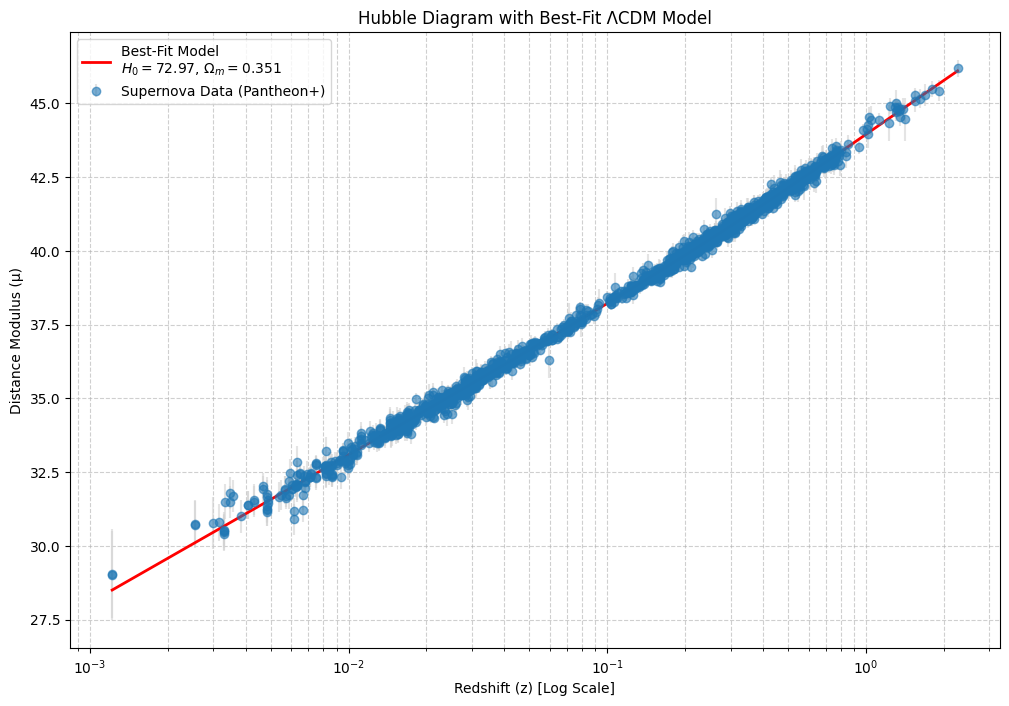

In [23]:

p0 = [70, 0.3]
popt, pcov = curve_fit(mu_theory, redshift_z, distance_modulus_µ, p0=p0, sigma=dist_mod_err_data_σ, absolute_sigma=True)
H0_fit, Omega_m_fit = popt
errors = np.sqrt(np.diag(pcov))
H0_err, Omega_m_err = errors

print(f"Fitted H0 = {H0_fit:.2f} ± {H0_err:.2f} km/s/Mpc")
print(f"Fitted Omega_m = {Omega_m_fit:.3f} ± {Omega_m_err:.3f}")

# --- Plot the Hubble Diagram with the Model Fit ---
z_fit_range = np.linspace(min(redshift_z), max(redshift_z), 500)
mu_fit = mu_theory(z_fit_range, H0_fit, Omega_m_fit)
plt.figure(figsize=(12, 8))
plt.errorbar(
    redshift_z, 
    distance_modulus_µ, 
    yerr=dist_mod_err_data_σ, 
    fmt='o', 
    alpha=0.6, 
    label='Supernova Data (Pantheon+)', 
    ecolor='lightgray', 
    capsize=0
)
plt.plot(
    z_fit_range, 
    mu_fit, 
    'r-', 
    linewidth=2, 
    label=f'Best-Fit Model\n$H_0={H0_fit:.2f}$, $\\Omega_m={Omega_m_fit:.3f}$'
)

plt.xscale('log')
plt.xlabel("Redshift (z) [Log Scale]")
plt.ylabel("Distance Modulus (μ)")
plt.title("Hubble Diagram with Best-Fit ΛCDM Model")
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## ⏳ Estimate the Age of the Universe

Now that we have the best-fit values of $ H_0 $ and $ \Omega_m $, we can estimate the age of the universe. This is done by integrating the inverse of the Hubble parameter over redshift:

$$
t_0 = \int_0^\infty \frac{1}{(1 + z) H(z)} \, dz
$$

We convert $ H_0 $ to SI units and express the result in gigayears (Gyr). This provides an independent check on our cosmological model by comparing the estimated age to values from other probes like Planck CMB measurements.


In [18]:
def age_of_universe(H0, Omega_m):
    age_integrand = lambda z: 1 / ((1 + z) * E(z, Omega_m))
    integral_val, _ = quad(age_integrand, 0, np.inf)
    hubble_time_in_Gyr = (1 / (H0 * u.km / u.s / u.Mpc)).to(u.Gyr).value
    return hubble_time_in_Gyr * integral_val

t0 = age_of_universe(H0_fit, Omega_m_fit)
print(f"Estimated age of Universe: {t0:.2f} Gyr")

Estimated age of Universe: 12.36 Gyr


## 📊 Analyze Residuals

To evaluate how well our cosmological model fits the data, we compute the residuals:

$$
\text{Residual} = \mu_{\text{obs}} - \mu_{\text{model}}
$$

Plotting these residuals against redshift helps identify any systematic trends, biases, or outliers. A good model fit should show residuals scattered randomly around zero without any significant structure.


Plotting residuals against redshift to check for systematic trends...


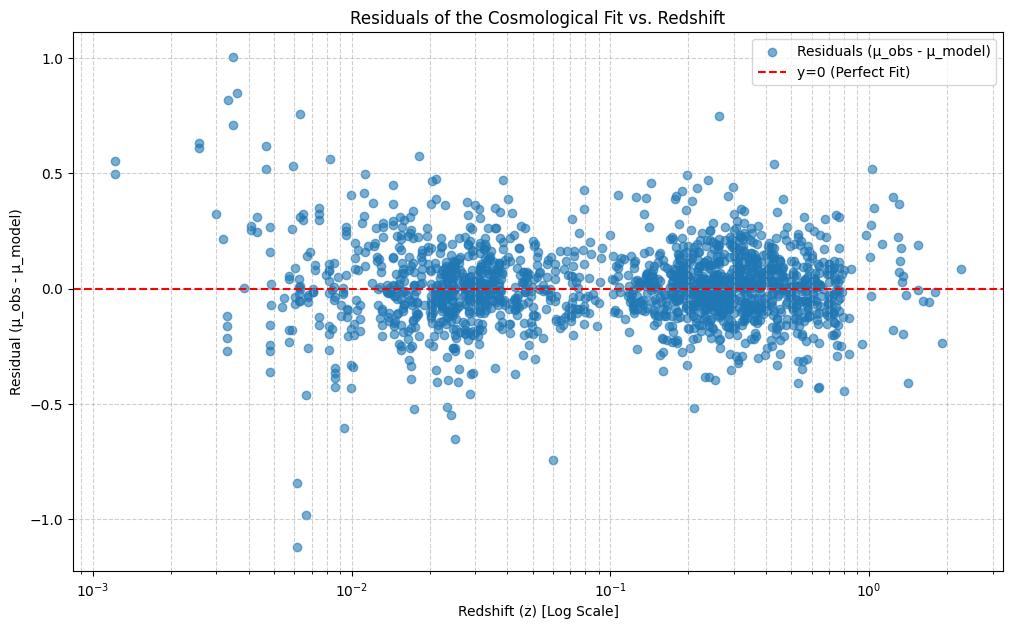


Plotting the histogram of residuals to check their distribution...


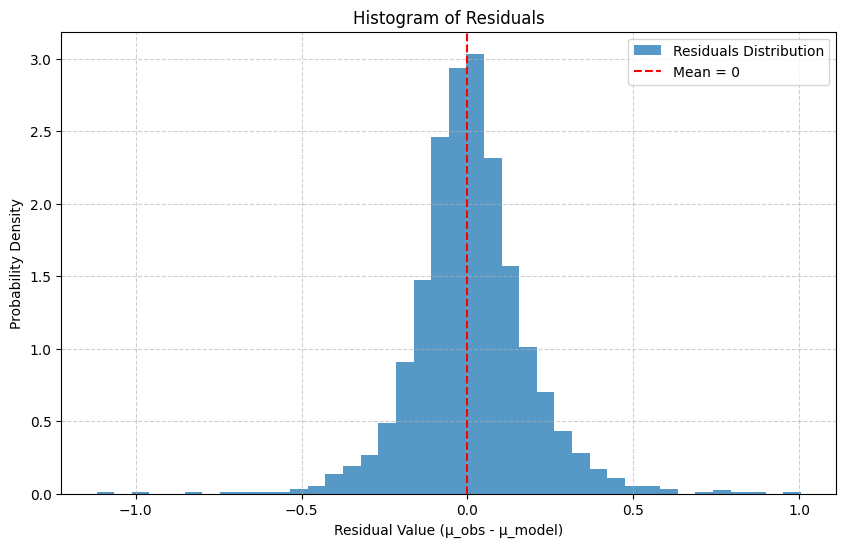

In [17]:
mu_model = mu_theory(redshift_z, H0_fit, Omega_m_fit)
residuals = distance_modulus_µ - mu_model

# --- Plot 1: Residuals vs. Redshift ---
print("Plotting residuals against redshift to check for systematic trends...")
plt.figure(figsize=(12, 7))
plt.scatter(redshift_z, residuals, alpha=0.6, label='Residuals (μ_obs - μ_model)')
plt.axhline(0, color='red', linestyle='--', label='y=0 (Perfect Fit)')

# A logarithmic x-axis 
plt.xscale('log')
plt.xlabel("Redshift (z) [Log Scale]")
plt.ylabel("Residual (μ_obs - μ_model)")
plt.title("Residuals of the Cosmological Fit vs. Redshift")
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# --- Plot 2: Histogram of Residuals ---
print("\nPlotting the histogram of residuals to check their distribution...")
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=40, alpha=0.75, density=True, label='Residuals Distribution')
plt.axvline(0, color='red', linestyle='--', label='Mean = 0')
plt.xlabel("Residual Value (μ_obs - μ_model)")
plt.ylabel("Probability Density")
plt.title("Histogram of Residuals")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



## 🔧 Fit with Fixed Matter Density

To reduce parameter degeneracy, let's fix $ \Omega_m = 0.3 $ and fit only for the Hubble constant $ H_0 $.


In [16]:
def mu_fixed_Om(z, H0):
    return mu_theory(z, H0, Omega_m=0.3)

# Initial guess for the Hubble constant H0.
p0_fixed = [70]

print("Fitting for H0 with Omega_m fixed at 0.3...")

popt_fixed, pcov_fixed = curve_fit(
    mu_fixed_Om,
    redshift_z,
    distance_modulus_µ,
    p0=p0_fixed,
    sigma=dist_mod_err_data_σ
)

H0_fit_fixed = popt_fixed[0]
H0_err_fixed = np.sqrt(np.diag(pcov_fixed))[0]

print(f"\n--- Fit Results with Fixed Omega_m ---")
print(f"Fitted H0 = {H0_fit_fixed:.2f} ± {H0_err_fixed:.2f} km/s/Mpc")


Fitting for H0 with Omega_m fixed at 0.3...

--- Fit Results with Fixed Omega_m ---
Fitted H0 = 73.53 ± 0.11 km/s/Mpc


## 🔍 Compare Low-z and High-z Subsamples

Finally, we examine whether the inferred value of $H_0$ changes with redshift by splitting the dataset into:
- **Low-z** supernovae ($ z < 0.1 $)
- **High-z** supernovae ($ z \geq 0.1 $)

We then fit each subset separately (keeping $ \Omega_m = 0.3 $) to explore any potential tension or trend with redshift.


In [14]:
z_split = 0.1
low_z_mask = redshift_z < z_split
high_z_mask = redshift_z >= z_split

# Low-z data
z_low = redshift_z[low_z_mask]
mu_low = distance_modulus_µ[low_z_mask]
sigma_low = dist_mod_err_data_σ[low_z_mask]

# High-z data
z_high = redshift_z[high_z_mask]
mu_high = distance_modulus_µ[high_z_mask]
sigma_high = dist_mod_err_data_σ[high_z_mask]

print(f"Splitting data at z = {z_split}:")
print(f"Number of low-z supernovae: {len(z_low)}")
print(f"Number of high-z supernovae: {len(z_high)}\n")

# --- Fit the Low-z Subsample ---
print("Fitting the low-z subsample...")
popt_low, pcov_low = curve_fit(mu_fixed_Om, z_low, mu_low, p0=[70], sigma=sigma_low)
H0_low = popt_low
H0_err_low = np.sqrt(np.diag(pcov_low))

# --- Fit the High-z Subsample ---
print("Fitting the high-z subsample...")
popt_high, pcov_high = curve_fit(mu_fixed_Om, z_high, mu_high, p0=[70], sigma=sigma_high)
H0_high = popt_high
H0_err_high = np.sqrt(np.diag(pcov_high))

# --- Print and Compare Results ---
print(f"\n--- Fit Results for Subsamples (Fixed Ω_m = 0.3) ---")
print(f"Low-z (z < {z_split}):  H₀ = {H0_low[0]:.2f} ± {H0_err_low[0]:.2f} km/s/Mpc")
print(f"High-z (z ≥ {z_split}): H₀ = {H0_high[0]:.2f} ± {H0_err_high[0]:.2f} km/s/Mpc")

Splitting data at z = 0.1:
Number of low-z supernovae: 741
Number of high-z supernovae: 960

Fitting the low-z subsample...
Fitting the high-z subsample...

--- Fit Results for Subsamples (Fixed Ω_m = 0.3) ---
Low-z (z < 0.1):  H₀ = 73.01 ± 0.19 km/s/Mpc
High-z (z ≥ 0.1): H₀ = 73.85 ± 0.14 km/s/Mpc
